setup.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, broadcast, desc

spark = SparkSession.builder \
    .appName('FB_API_v3_build') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


26/05/17 09:32:37 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


paths.

In [2]:
V2_PATH           = '/user/s3348393/main/preprocessing/v2/parquet'
INTERMEDIATE_PATH = '/user/s3348393/main/preprocessing/v3/intermediate_parquet'
V3_PATH           = '/user/s3348393/main/preprocessing/v3/parquet'
TOPIC_LABELS_CSV  = '../data/topic_labels.csv'

join labels and topic info onto v2. three inputs combined. v2 parquet (one row per ad via ad_seq_no = 1) — every ad with match_type and political_party. intermediate parquet (residual subset only, with topic_id + topicDistribution) from nb 03. topic_labels.csv — hand-edited labels with topic_label and category.


In [3]:
import pandas as pd

v2 = spark.read.parquet(V2_PATH).filter(col('ad_seq_no') == 1)

intermediate = spark.read.parquet(INTERMEDIATE_PATH).select('id', 'topic_id', 'topicDistribution', 'body')

#load the data labels using pandas on local
labels_pdf = pd.read_csv(TOPIC_LABELS_CSV)[['topic_id', 'label', 'category']]
labels = spark.createDataFrame(labels_pdf).withColumnRenamed('label', 'topic_label')

classified = v2.join(intermediate, 'id', 'left').join(broadcast(labels), 'topic_id', 'left').cache()

print(f'All ads (ad_seq_no=1): {classified.count():,}')
print(f'  with topic info:    {classified.filter(col("topic_id").isNotNull()).count():,}')
print(f'  without topic info: {classified.filter(col("topic_id").isNull()).count():,}')

26/05/17 09:32:53 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/05/17 09:33:08 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/05/17 09:33:23 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/05/17 09:33:38 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/05/17 09:33:53 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/05/17 09:34:08 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registere

All ads (ad_seq_no=1): 151,578
  with topic info:    94,358
  without topic info: 57,220


qc - check counts to make sure everything's tagged properly

In [4]:
print('match_type × category:')
classified.groupBy('match_type', 'category').count() \
    .orderBy('match_type', 'category') \
    .show(50, truncate=False)

# Belt-and-braces: did any topic_id end up unmatched in the labels CSV?
unmatched = classified.filter(col('topic_id').isNotNull() & col('topic_label').isNull()).count()
print(f'Rows with topic_id but no topic_label (should be 0): {unmatched}')

match_type × category:
+----------+-------------------+-----+
|match_type|category           |count|
+----------+-------------------+-----+
|NULL      |NULL               |9523 |
|NULL      |climate            |28981|
|NULL      |cost_of_living     |6359 |
|NULL      |humanitarian_rights|9076 |
|NULL      |mixed              |15834|
|NULL      |political_advocacy |34108|
|candidate |NULL               |23327|
|commercial|NULL               |3    |
|government|NULL               |1219 |
|party_org |NULL               |23148|
+----------+-------------------+-----+

Rows with topic_id but no topic_label (should be 0): 0


drop government and commercial rows

In [5]:
before = classified.count()

v3_candidate = classified.filter(
    col('match_type').isin('candidate', 'party_org')
    | (col('match_type').isNull() & col('category').isNotNull())
)
v3_candidate.cache()
after = v3_candidate.count()

print(f'Before filter: {before:,}')
print(f'After filter:  {after:,}')
print(f'Dropped:       {before - after:,}  ({100 * (before - after) / before:.1f}%)')

print('\nKept rows by match_type × category:')
v3_candidate.groupBy('match_type', 'category').count().orderBy('match_type', 'category').show(50, truncate=False)

Before filter: 151,578
After filter:  140,833
Dropped:       10,745  (7.1%)

Kept rows by match_type × category:
+----------+-------------------+-----+
|match_type|category           |count|
+----------+-------------------+-----+
|NULL      |climate            |28981|
|NULL      |cost_of_living     |6359 |
|NULL      |humanitarian_rights|9076 |
|NULL      |mixed              |15834|
|NULL      |political_advocacy |34108|
|candidate |NULL               |23327|
|party_org |NULL               |23148|
+----------+-------------------+-----+



visualise the breakdown

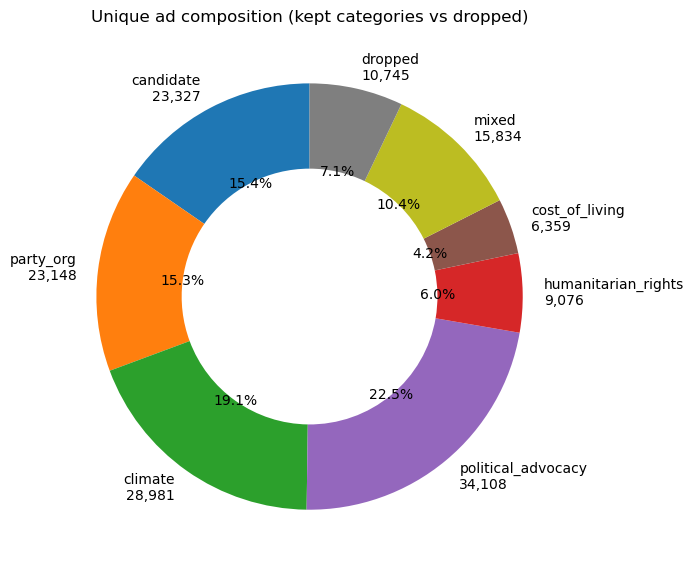

In [6]:
import matplotlib.pyplot as plt

# Kept slices come from v3_candidate (already grouped by match_type × category above).
# match_type ∈ {candidate, party_org} → slice keyed by match_type;
# match_type IS NULL → slice keyed by category.
kept_pdf = v3_candidate.groupBy('match_type', 'category').count().toPandas()

slices = {}
for _, r in kept_pdf.iterrows():
    key = r['match_type'] if r['match_type'] in ('candidate', 'party_org') else r['category']
    slices[key] = slices.get(key, 0) + int(r['count'])

# Single 'dropped' slice = everything filter excluded (government + noise + residual with no topic).
slices['dropped'] = classified.count() - v3_candidate.count()

order = ['candidate', 'party_org',
         'climate', 'political_advocacy', 'humanitarian_rights', 'cost_of_living', 'mixed','dropped']
colors = {
    'candidate':           '#1f77b4',
    'party_org':           '#ff7f0e',
    'climate':             '#2ca02c',
    'political_advocacy':  '#9467bd',
    'humanitarian_rights': '#d62728',
    'cost_of_living':      '#8c564b',
    'mixed':               '#bcbd22',
    'dropped':             '#7f7f7f',
}

sizes  = [slices[k] for k in order]
labels = [f'{k}\n{slices[k]:,}' for k in order]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    sizes,
    labels=labels,
    colors=[colors[k] for k in order],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4),
)
ax.set_title('Unique ad composition (kept categories vs dropped)')
plt.tight_layout()
plt.show()

i havent dropped mixed at this point. lets check false positives and false negatives.



In [9]:
# --- False positives: top-spend ads in each kept category ---

for cat in ['climate', 'humanitarian_rights', 'political_advocacy', 'cost_of_living']:
    print(f'\n--- {cat} ---')
    v3_candidate.filter((col('category') == cat) & (col('spend_mid').isNotNull())) \
        .orderBy(desc('spend_mid')) \
        .select('page_name', 'bylines') \
        .distinct() \
        .show(5, truncate=60)

# Also: top-spend candidate + party_org
print('\n=== FP check: top-spend candidate + party_org ads ===')
v3_candidate.filter(col('match_type').isin('candidate', 'party_org') & col('spend_mid').isNotNull()) \
    .orderBy(desc('spend_mid')) \
    .select('page_name', 'bylines', 'political_party') \
    .distinct() \
    .show(10, truncate=60)

# --- False negatives: top bylines in dropped noise topics ---
print('\n=== FN check: top bylines in DROPPED noise-labelled topics ===')
classified.filter(col('category') == 'noise') \
    .groupBy('topic_label', 'bylines').count() \
    .orderBy(desc('count')) \
    .show(20, truncate=80)

# --- False negatives: top bylines in residual with no topic_id ---
print('\n=== FN check: top bylines in residual with NO topic_id (empty body / non-English / commercial bylines) ===')
classified.filter(col('match_type').isNull() & col('topic_id').isNull() & col('bylines').isNotNull()) \
    .groupBy('bylines').count() \
    .orderBy(desc('count')) \
    .show(20, truncate=80)


--- climate ---
+--------------------+-----------------------------------------------+
|           page_name|                                        bylines|
+--------------------+-----------------------------------------------+
|  David Southwick MP|                              David J Southwick|
|  Michael O'Brien MP|The Hon. Michael O'Brien MP, Member for Malvern|
|Great Plastic Rescue|                           Great Plastic Rescue|
|      Save Our Spuds|                                   Glen F Jones|
|Double It For Nature|                           Double It For Nature|
+--------------------+-----------------------------------------------+
only showing top 5 rows


--- humanitarian_rights ---
+-----------------------------------+--------------------------+
|                          page_name|                   bylines|
+-----------------------------------+--------------------------+
|                 David Southwick MP|         David J Southwick|
|                     Wayside 

weekly spend by issue category - one panel per category, over the election window.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql.functions import date_trunc, sum as spark_sum

ELECTION_DATE = pd.Timestamp('2022-05-21')

CATEGORY_COLORS = {
    'political_advocacy':  '#9467bd',
    'climate':             '#2ca02c',
    'humanitarian_rights': '#d62728',
    'cost_of_living':      '#8c564b',
    'mixed':               '#bcbd22',
}

CATEGORY_LABELS = {
    'political_advocacy':  'Political advocacy',
    'climate':             'Climate and environment',
    'humanitarian_rights': 'Humanitarian and rights',
    'cost_of_living':      'Cost of living',
    'mixed':               'Mixed',
}

# weekly spend - residual (non-candidate/party_org) categories only.
# filter out malformed dates (a few rows carry epoch-era timestamps).
cat_weekly = (
    v3_candidate
    .filter(
        col('match_type').isNull()
        & col('category').isNotNull()
        & col('spend_mid').isNotNull()
        & col('ad_creation_date').isNotNull()
        & (col('ad_creation_date') >= '2021-01-01')
    )
    .withColumn('week', date_trunc('week', 'ad_creation_date'))
    .groupBy('week', 'category')
    .agg(spark_sum('spend_mid').alias('spend'))
    .orderBy('week')
    .toPandas()
)

cat_weekly['week'] = pd.to_datetime(cat_weekly['week'])

# pivot to week x category. pivot_table keeps the native (Monday-anchored)
# weekly index, so no reindex is needed - missing cells just fill to 0.
pivot = (cat_weekly
         .pivot_table(index='week', columns='category', values='spend', aggfunc='sum')
         .sort_index()
         .fillna(0))

# 3-week centred rolling mean to take the edge off weekly noise.
pivot_smooth = pivot.rolling(3, center=True, min_periods=1).mean()

# order panels by total spend, largest first.
cat_order = pivot.sum().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(len(cat_order), 1,
                         figsize=(12, 2.6 * len(cat_order)), sharex=True)

for ax, cat in zip(axes, cat_order):
    series = pivot_smooth[cat]
    color = CATEGORY_COLORS[cat]
    ax.fill_between(series.index, series.values, alpha=0.7, color=color)
    ax.plot(series.index, series.values, color=color, linewidth=1)
    ax.axvline(ELECTION_DATE, linestyle='--', color='black', alpha=0.7, linewidth=1.2)
    ax.set_title(CATEGORY_LABELS[cat], fontsize=11, color=color,
                 fontweight='bold', loc='left')
    ax.set_ylabel('Weekly spend (A$)', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:,.0f}k'))
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

axes[0].set_xlim(pivot_smooth.index.min(), pivot_smooth.index.max())

# election-day label on the top panel only.
axes[0].text(ELECTION_DATE + pd.Timedelta(days=4),
             axes[0].get_ylim()[1] * 0.88,
             'Election day\n21 May 2022',
             color='black', va='top', fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[-1].get_xticklabels(), rotation=30, ha='right')

fig.suptitle('Weekly spend by issue category - non-government advertisers',
             fontsize=13)
plt.tight_layout()

FIG_PATH = '../report/figures/category_weekly_spend.png'
plt.savefig(FIG_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIG_PATH}')